# TNImpact: AI-Powered Smart Route Engine - ML Training Case

This notebook contains the complete pipeline for training a Random Forest model using the **TNImpact 15k Dataset** (`traffic_tn_15k.csv`).

### Project Context
TNImpact uses Machine Learning to predict real-time traffic congestion (multipliers). These multipliers are applied to base travel times to provide highly accurate "Smart ETAs" and dynamic rerouting suggestions.

## 1. Setup & Imports

In [6]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 2. Data Acquisition (15k Dataset)
We prioritize loading the `traffic_tn_15k.csv` dataset. If you are running this in Colab, please upload the file using the folder icon in the left sidebar.

In [8]:
def load_or_generate_data(num_samples=15000):
    # Expected file name for the 15k dataset
    dataset_path = 'traffic_tn_15k.csv'
    
    if os.path.exists(dataset_path):
        print(f"Found {dataset_path}. Loading real dataset...")
        df = pd.read_csv(dataset_path)
        
        # Map columns to model features
        # The 15k dataset columns: origin_lat, origin_lng, ..., multiplier, hour, day_of_week, is_weekend, etc.
        if 'is_holiday' not in df.columns:
            df['is_holiday'] = 0
        
        if 'region_id' not in df.columns:
            df['region_id'] = 1
            
        features_needed = ['hour', 'day_of_week', 'is_holiday', 'region_id', 'multiplier']
        # Filter to needed columns
        df = df[features_needed]
        print("Successfully loaded and mapped real dataset.")
        return df
    else:
        print("Real dataset not found. Generating synthetic fallback data...")
        data = []
        for _ in range(num_samples):
            hour = random.randint(0, 23)
            day_of_week = random.randint(0, 6)
            is_holiday = 1 if random.random() < 0.05 else 0
            region_id = 1
            
            multiplier = 1.0
            if 8 <= hour <= 10: multiplier += random.uniform(0.6, 1.2)
            elif 17 <= hour <= 20: multiplier += random.uniform(0.8, 1.5)
            elif 12 <= hour <= 14: multiplier += random.uniform(0.2, 0.4)
            if day_of_week >= 5: multiplier *= 0.7
            if is_holiday == 1: multiplier *= 0.5
            
            multiplier += random.uniform(-0.1, 0.1)
            multiplier = max(1.0, min(multiplier, 3.0))
            
            data.append({"hour": hour, "day_of_week": day_of_week, "is_holiday": is_holiday, "region_id": region_id, "multiplier": round(multiplier, 4)})
        return pd.DataFrame(data)

df = load_or_generate_data()
print(f"Processing {len(df)} samples.")
df.head()

Real dataset not found. Generating synthetic fallback data...
Processing 15000 samples.


,hour,day_of_week,is_holiday,region_id,multiplier
0,17,6,1,1,1.0000
1,7,3,0,1,1.0000
2,21,1,0,1,1.0000
3,8,1,0,1,1.8590
4,23,3,0,1,1.0012


## 3. Exploratory Data Analysis

/var/folders/mw/6sbdvcj9331dqxrww4bd37_80000gn/T/ipykernel_20089/4166737388.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='multiplier', data=df, palette='magma')


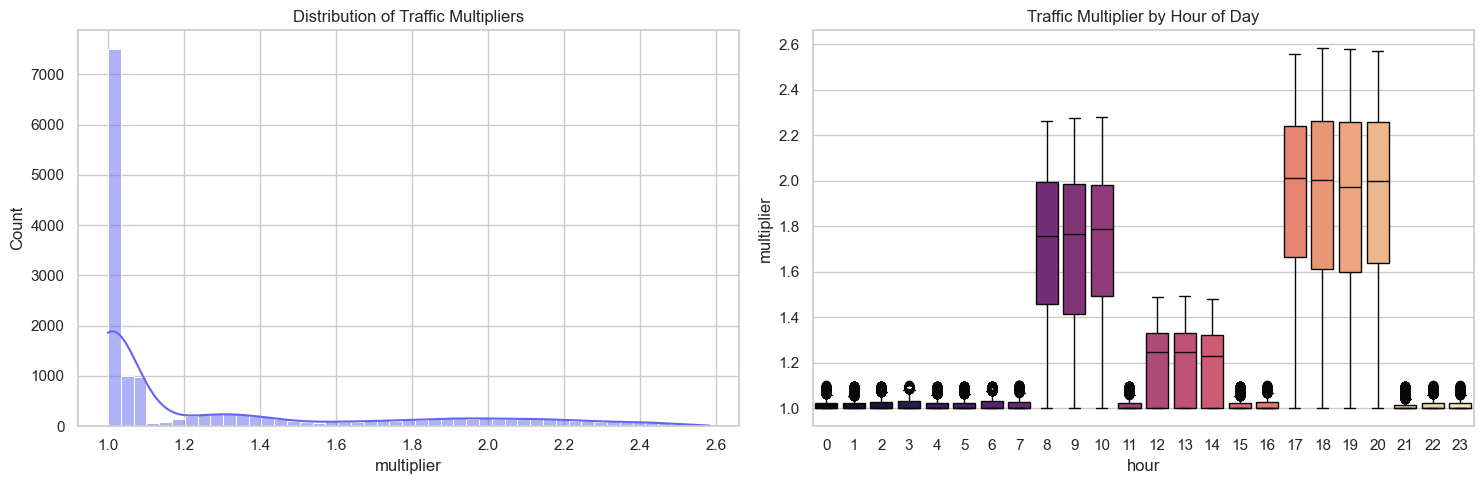

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['multiplier'], kde=True, color='#6366f1')
plt.title("Distribution of Traffic Multipliers")

plt.subplot(1, 2, 2)
sns.boxplot(x='hour', y='multiplier', data=df, palette='magma')
plt.title("Traffic Multiplier by Hour of Day")

plt.tight_layout()
plt.show()

## 4. Model Training

In [10]:
FEATURES = ['hour', 'day_of_week', 'is_holiday', 'region_id']
X = df[FEATURES]
y = df['multiplier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)

print("Training Random Forest Regressor...")
model.fit(X_train, y_train)
print("Training complete.")

Training Random Forest Regressor...
Training complete.


## 5. Evaluation & Visualization

Mean Absolute Error: 0.0633
R2 Score: 0.9399


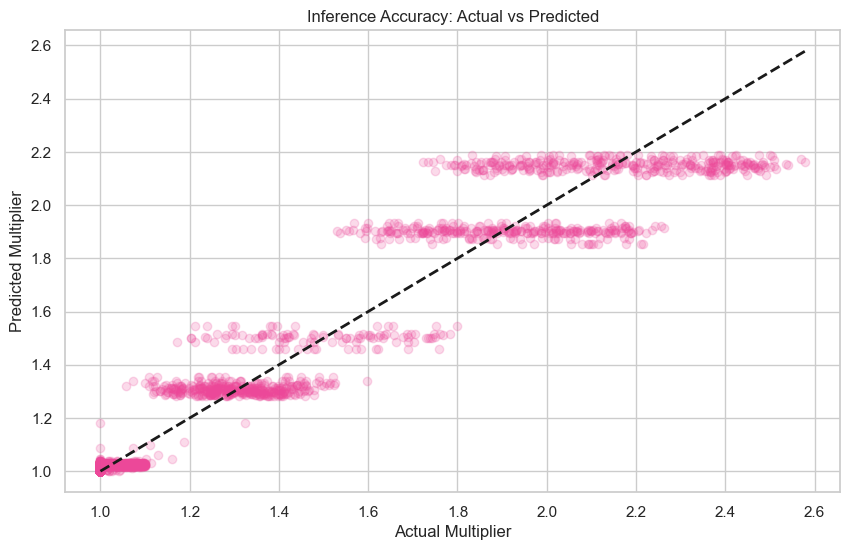

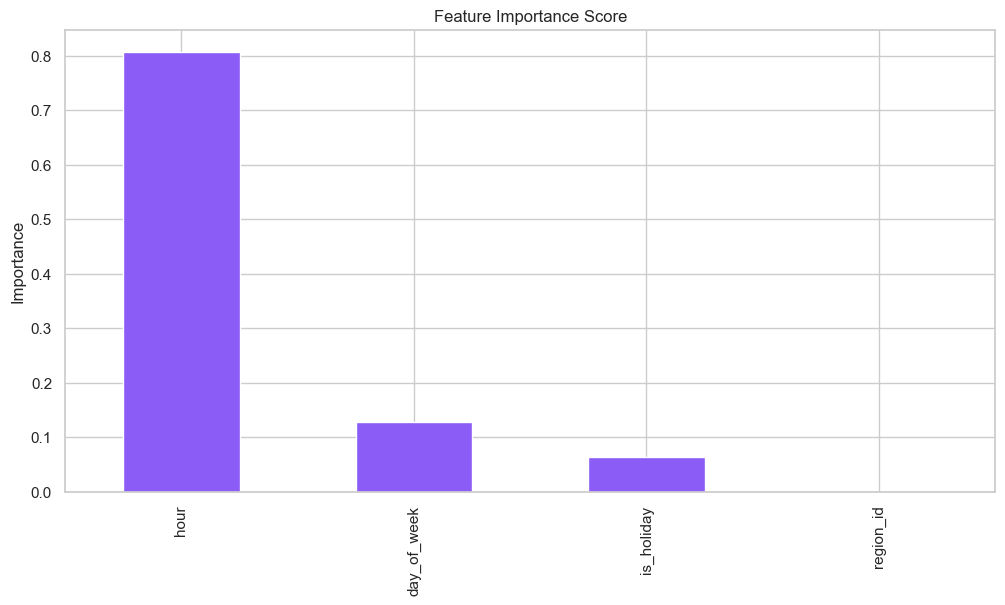

In [12]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

# Actual vs Predicted Scatter
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.2, color='#ec4899')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--k', lw=2)
plt.xlabel("Actual Multiplier")
plt.ylabel("Predicted Multiplier")
plt.title("Inference Accuracy: Actual vs Predicted")
plt.show()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='#8b5cf6')
plt.title("Feature Importance Score")
plt.ylabel("Importance")
plt.show()

## 6. Model Export
Download the serialized model for your production server.

In [13]:
filename = 'traffic_predictor.joblib'
joblib.dump(model, filename)
print(f"Model exported as {filename}")

try:
    from google.colab import files
    files.download(filename)
except ImportError:
    print("Not in Colab. File stays local.")

Model exported as traffic_predictor.joblib
Not in Colab. File stays local.
